# HoloMine Paddy Field Segmentation — Babak Final

Notebook ini melatih ulang seluruh solusi dari file kompetisi dan menulis `/kaggle/working/submission.csv`.

**Solusi:** empat model segmentasi dilatih secara *supervised* pada tile train berlabel, probabilitasnya dirata-rata dengan bobot sama, lalu bentuk mask dirapikan.

| Model | Encoder | Decoder | Pretraining |
|---|---|---|---|
| `dinov3_sat` | DINOv3 ViT-L/16 | head konvolusi ringan | SAT-493M (citra satelit) |
| `unetpp_effv2l` | EfficientNetV2-L | UNet++ | ImageNet |
| `upernet_swinl` | Swin-L | UPerNet | ImageNet-22k + ADE20K |
| `mask2former_swinl` | Swin-L | Mask2Former | ImageNet-22k + ADE20K |

Tidak ada pseudo-label, tidak ada data eksternal, tidak ada label test. Tile test hanya dipakai saat inferensi.

**Isi notebook**
1. EDA — seperti apa tile dan labelnya, dan bagaimana test berbeda dari train.
2. Preprocessing — split validasi, augmentasi, normalisasi, penanganan nodata, perapian mask.
3. Training keempat model.
4. Ensemble dan submission.
5. Referensi.

Input: `/kaggle/input/competitions/holomine-paddy-field-segmentation-finals` (`train/images`, `train/masks`, `test_images`, `sample_submission.csv`).
Training butuh GPU (Mask2Former butuh ±40 GB pada batch 4) dan internet untuk mengunduh backbone pretrained publik. Setiap model yang selesai disimpan di `/kaggle/working/probs`, sehingga sesi yang terputus melanjutkan dari model berikutnya.
Pelatihan di GPU tidak bit-identik antar run; skor dapat bergeser beberapa per seribu.

Cell EDA dan preprocessing di bawah ditampilkan beserta outputnya (CPU). Cell training belum dijalankan.

In [ ]:
!pip -q install segmentation-models-pytorch==0.5.0 timm==1.0.20 albumentations==2.0.8 huggingface_hub==0.36.0 transformers==4.57.6 scipy

In [ ]:
%%writefile paddy_repro.py
"""HoloMine paddy-field segmentation: full retraining pipeline in one file.

Four segmentation models are trained on the labelled train tiles only, their test probabilities are averaged
with equal weights, and the mask shape is cleaned:

    DINOv3 ViT-L/16 (satellite pretraining) + conv head
    UNet++ with EfficientNetV2-L encoder
    UPerNet with Swin-L backbone
    Mask2Former with Swin-L backbone

    mean probability -> blur sigma=2 -> threshold 0.35 -> closing 15 px
                     -> fill holes < 2000 px -> remove regions < 5000 px -> RLE

Supervised training only: no pseudo-labels, no external data, no test labels. Uses the competition files
<DATA>/train/images, <DATA>/train/masks, <DATA>/test_images, <DATA>/sample_submission.csv and public
pretrained backbones (timm, segmentation-models-pytorch, Hugging Face transformers).

    python paddy_repro.py --data /kaggle/input/competitions/holomine-paddy-field-segmentation-finals --work /kaggle/working

GPU training is not bit-reproducible; expect the score to move by a few 0.001 between runs.
"""
import argparse
import os
import random
from pathlib import Path

import albumentations as A
import cv2
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import timm
import torch
from torch import nn

MODELS = {
    "dinov3_sat": dict(arch="dinov3", encoder="vit_large_patch16_dinov3.sat493m"),
    "unetpp_effv2l": dict(arch="UnetPlusPlus", encoder="tu-tf_efficientnetv2_l"),
    "upernet_swinl": dict(arch="hf_upernet", encoder="openmmlab/upernet-swin-large"),
    # fp32: deformable attention and Hungarian matching are not fp16-safe; needs ~40 GB at batch 4
    "mask2former_swinl": dict(arch="mask2former", encoder="facebook/mask2former-swin-large-ade-semantic",
                              amp=False, big=True),
}
ENSEMBLE = list(MODELS)   # equal weights
EPOCHS = 60
CROP, BATCH, SEED = 768, 4, 2026
FOLDS = 5                 # one fold (25 tiles) is held out for a validation read-out
FINAL = dict(thr=0.35, sigma=2, close=15, hole=2000, speck=5000)
H = W = 1024


class Dino(nn.Module):
    """DINOv3 ViT-L/16 backbone + small conv head on four intermediate layers (1/16 -> 1/4 -> input size)."""

    def __init__(self, encoder, pretrained=True):
        super().__init__()
        self.vit = timm.create_model(encoder, pretrained=pretrained)
        n = len(self.vit.blocks)
        self.idx = [n // 4 - 1, n // 2 - 1, 3 * n // 4 - 1, n - 1]
        self.head = nn.Sequential(
            nn.Conv2d(4 * self.vit.embed_dim, 256, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 2, 2), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 2, 2), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 1, 3, padding=1),
        )

    def forward(self, x):  # H, W multiples of 16
        f = self.vit.forward_intermediates(x, indices=self.idx, intermediates_only=True)
        return nn.functional.interpolate(self.head(torch.cat(f, 1)), x.shape[2:], mode="bilinear")


class HFSeg(nn.Module):
    """Hugging Face UPerNet / Mask2Former behind one interface: model(x) -> paddy logits Bx1xHxW.
    Mask2Former only: model(x, y) -> its own set-prediction loss."""

    def __init__(self, net, m2f):
        super().__init__()
        self.net, self.m2f = net, m2f

    def forward(self, x, y=None):
        if not self.m2f:
            return self.net(pixel_values=x).logits
        if y is not None:  # one binary mask per class present in the crop
            cl = [torch.unique(m).long() for m in y[:, 0]]
            ml = [torch.stack([(m == k).float() for k in c]) for m, c in zip(y[:, 0], cl)]
            return self.net(pixel_values=x, mask_labels=ml, class_labels=cl).loss
        o = self.net(pixel_values=x)
        seg = torch.einsum("bqc,bqhw->bchw", o.class_queries_logits.softmax(-1)[..., :-1],
                           o.masks_queries_logits.sigmoid())
        seg = nn.functional.interpolate(seg, x.shape[2:], mode="bilinear")
        p = seg[:, 1:2] / (seg.sum(1, keepdim=True) + 1e-6)
        return torch.logit(p.clamp(1e-4, 1 - 1e-4))


def build(name, pretrained=True):
    """-> model, mean, std, optimizer parameter groups (pretrained backbones train at 0.1x the head rate)."""
    cfg = MODELS[name]
    imagenet = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
    if cfg["arch"] == "dinov3":
        model = Dino(cfg["encoder"], pretrained)
        pc = model.vit.pretrained_cfg  # satellite statistics, not ImageNet
        return model, pc["mean"], pc["std"], [dict(params=model.head.parameters(), lr=1e-4),
                                              dict(params=model.vit.parameters(), lr=1e-5)]
    if cfg["arch"] in ("hf_upernet", "mask2former"):
        import transformers as T

        m2f = cfg["arch"] == "mask2former"
        cls = T.Mask2FormerForUniversalSegmentation if m2f else T.UperNetForSemanticSegmentation
        n = 2 if m2f else 1  # Mask2Former: background + paddy queries; UPerNet: one paddy logit
        net = (cls.from_pretrained(cfg["encoder"], num_labels=n, ignore_mismatched_sizes=True) if pretrained
               else cls(T.AutoConfig.from_pretrained(cfg["encoder"], num_labels=n)))
        bb = net.model.pixel_level_module.encoder if m2f else net.backbone
        skip = {id(p) for p in bb.parameters()}
        groups = [dict(params=[p for p in net.parameters() if id(p) not in skip], lr=1e-4),
                  dict(params=bb.parameters(), lr=1e-5)]
        return HFSeg(net, m2f), *imagenet, groups
    model = getattr(smp, cfg["arch"])(cfg["encoder"], encoder_weights="imagenet" if pretrained else None, classes=1)
    return model, *imagenet, [dict(params=model.parameters(), lr=1e-4)]


def read_rgb(p):
    return cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)


def holdout(n, fold=0):
    """Validation tile indices: every FOLDS-th tile of a fixed random permutation."""
    return sorted(np.random.RandomState(0).permutation(n)[fold::FOLDS].tolist())


def tile_groups(imgs):
    """Analysis helper (not used in training). Tiles were cut with a 512 px stride, so neighbours share half
    their area; tiles sharing a 512x512 quadrant get the same group id. Found from pixels only."""
    desc, key = [], []
    for i, im in enumerate(imgs):
        g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
        for r in (0, 1):
            for c in (0, 1):
                q = g[r * 512:(r + 1) * 512, c * 512:(c + 1) * 512]
                if (q == 0).mean() <= 0.5:  # skip nodata quadrants, they all look alike
                    desc.append(cv2.resize(q, (24, 24), interpolation=cv2.INTER_AREA).astype(np.float32).ravel())
                    key.append(i)
    d = np.stack(desc)
    d2 = ((d ** 2).sum(1)[:, None] + (d ** 2).sum(1)[None] - 2 * d @ d.T) / d.shape[1]
    parent = list(range(len(imgs)))

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    for a, b in zip(*np.where(d2 < 9)):  # rms < 3 grey levels: overlaps are resampled, not bit-identical
        parent[find(key[a])] = find(key[b])
    return [find(i) for i in range(len(imgs))]


def make_aug():
    """Training augmentation: random scale crop (0.25-1.0 of the tile) to 768 px, flips, 90-degree turns, mild colour."""
    return A.Compose([
        A.RandomResizedCrop(size=(CROP, CROP), scale=(0.25, 1.0), ratio=(0.75, 1.33)),
        A.HorizontalFlip(), A.VerticalFlip(), A.RandomRotate90(),
        A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
        A.HueSaturationValue(10, 15, 10, p=0.5),
    ])


def train_predict(name, data, work, epochs=EPOCHS, smoke=False):
    """Train one model, save its test probabilities to <work>/probs/<name>.npy (uint8, 255 = certain paddy)."""
    data, work = Path(data), Path(work)
    out = work / "probs" / f"{name}.npy"
    if out.exists():  # resume
        return str(out)
    out.parent.mkdir(parents=True, exist_ok=True)
    random.seed(SEED), np.random.seed(SEED), torch.manual_seed(SEED)
    dev = "cuda"

    ids = sorted(p.stem for p in (data / "train/images").glob("*.png"))
    test_ids = pd.read_csv(data / "sample_submission.csv").ImageId.tolist()
    if smoke:
        ids, test_ids, epochs = ids[:12], test_ids[:4], 1
    imgs = [read_rgb(data / f"train/images/{i}.png") for i in ids]
    masks = [(cv2.imread(str(data / f"train/masks/{i}.png"), 0) > 127).astype(np.float32) for i in ids]
    val = holdout(len(ids))
    trn = [i for i in range(len(ids)) if i not in set(val)]
    aug = make_aug()

    class DS(torch.utils.data.Dataset):
        def __len__(self):
            return len(trn) * 4  # four random crops per tile per epoch

        def __getitem__(self, k):
            i = trn[k % len(trn)]
            a = aug(image=imgs[i], mask=masks[i])
            return torch.from_numpy(a["image"]).permute(2, 0, 1), torch.from_numpy(a["mask"])[None]

    dl = torch.utils.data.DataLoader(DS(), BATCH, shuffle=True, drop_last=True,
                                     num_workers=min(8, os.cpu_count() or 1))
    cfg = MODELS[name]
    amp, own_loss = cfg.get("amp", True), cfg["arch"] == "mask2former"
    model, mean, std, groups = build(name)
    model.to(dev)
    mean = torch.tensor(mean, device=dev).view(1, 3, 1, 1) * 255
    std = torch.tensor(std, device=dev).view(1, 3, 1, 1) * 255

    def norm(x):
        return (x.to(dev).float() - mean) / std

    opt = torch.optim.AdamW(groups, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[g["lr"] for g in groups],
                                                total_steps=epochs * len(dl), pct_start=0.05)
    scaler = torch.amp.GradScaler("cuda", enabled=amp)
    bce, dice = nn.BCEWithLogitsLoss(), smp.losses.DiceLoss("binary")  # Dice over the batch, like the micro-IoU metric
    for ep in range(epochs):
        model.train()
        tot = 0.0
        for x, y in dl:
            y = y.to(dev)
            with torch.autocast("cuda", enabled=amp):
                o = model(norm(x), y) if own_loss else model(norm(x))
            o = o.float()
            loss = o if own_loss else bce(o, y) + dice(o, y)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            sched.step()
            tot += loss.item()
        print(f"{name} epoch {ep + 1}/{epochs} loss {tot / len(dl):.4f}", flush=True)

    model.eval()

    @torch.no_grad()
    def predict(img):
        """HxWx3 uint8 -> HxW uint8 probability, 4-flip test-time augmentation."""
        x = norm(torch.from_numpy(img).permute(2, 0, 1)[None])
        p = 0
        for d in ([], [2], [3], [2, 3]):
            with torch.autocast("cuda", enabled=amp):
                o = model(x.flip(d))
            p = p + o.float().sigmoid().flip(d)
        p = (p[0, 0] / 4).cpu().numpy()
        p[(img == 0).all(2)] = 0  # black nodata border is never paddy
        return np.round(p * 255).astype(np.uint8)

    inter = union = 0
    for i in val:
        p, g = predict(imgs[i]) > 127, masks[i] > 0
        inter, union = inter + (p & g).sum(), union + (p | g).sum()
    print(f"{name} validation micro-IoU on {len(val)} held-out train tiles: {inter / max(union, 1):.4f}", flush=True)
    np.save(out, np.stack([predict(read_rgb(data / f"test_images/{i}.png")) for i in test_ids]))
    torch.save({k: v.half() if v.is_floating_point() else v for k, v in model.state_dict().items()},
               work / "probs" / f"{name}.pt")
    return str(out)


def blend(work, names=ENSEMBLE):
    """Equal-weight mean probability of the given models -> float32 (N,1024,1024) in 0..1."""
    acc = 0
    for n in names:
        acc = acc + np.load(Path(work) / "probs" / f"{n}.npy").astype(np.float32)
    return acc / (255 * len(names))


def postprocess(prob, thr, sigma, close, hole, speck):
    """One tile: blur -> threshold -> closing -> fill small holes -> drop small regions.
    Train masks are coarse polygons (about one small hole per tile); raw predictions have hundreds."""
    if sigma:
        prob = cv2.GaussianBlur(prob, (0, 0), sigma)
    a = (prob > thr).astype(np.uint8)
    if close:
        a = cv2.morphologyEx(a, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close, close)))
    _, lab, st, _ = cv2.connectedComponentsWithStats(1 - a, connectivity=4)
    k = np.where(st[:, 4] < hole)[0]
    a[np.isin(lab, k[k > 0])] = 1
    _, lab, st, _ = cv2.connectedComponentsWithStats(a, connectivity=4)
    k = np.where(st[:, 4] < speck)[0]
    a[np.isin(lab, k[k > 0])] = 0
    return a > 0


def rle_encode(m):
    """Airbus-style RLE: column-major, 1-based start/length pairs, '' for an empty mask."""
    p = np.concatenate([[0], m.flatten(order="F").astype(np.uint8), [0]])
    r = np.where(p[1:] != p[:-1])[0] + 1
    r[1::2] -= r[::2]
    return " ".join(map(str, r))


def make_submission(data, work, names=ENSEMBLE):
    ids = pd.read_csv(Path(data) / "sample_submission.csv").ImageId.tolist()
    rows = [rle_encode(postprocess(p, **FINAL)) for p in blend(work, names)]
    path = Path(work) / "submission.csv"
    pd.DataFrame({"ImageId": ids[:len(rows)], "EncodedPixels": rows}).to_csv(path, index=False)
    return str(path)


def run_all(data, work, smoke=False):
    """Whole pipeline on one GPU, sequentially. Every finished model is cached, so a rerun resumes."""
    for m in ENSEMBLE:
        train_predict(m, data, work, smoke=smoke)
    return make_submission(data, work)


def _selfcheck():
    m = np.zeros((H, W), bool)
    m[:2, 0] = m[0, 1] = True
    assert rle_encode(m) == "1 2 1025 1" and rle_encode(np.zeros((H, W), bool)) == ""
    p = np.zeros((H, W), np.float32)
    p[100:400, 100:400] = 1
    p[200:210, 200:210] = 0   # small hole -> filled
    p[900:905, 900:905] = 1   # speck -> removed
    out = postprocess(p, thr=0.5, sigma=0, close=0, hole=2000, speck=2000)
    assert out[205, 205] and not out[902, 902] and out.sum() == 300 * 300
    v = holdout(123)
    assert len(v) == 25 and v == holdout(123), "validation split must be deterministic"


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", default="/kaggle/input/competitions/holomine-paddy-field-segmentation-finals")
    ap.add_argument("--work", default="/kaggle/working")
    ap.add_argument("--smoke", action="store_true", help="1 epoch on 12 tiles: checks every code path, not the score")
    a = ap.parse_args()
    _selfcheck()
    print("submission:", run_all(a.data, a.work, a.smoke))


In [1]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = "/kaggle/input/competitions/holomine-paddy-field-segmentation-finals"
TEST = DATA + "/test_images"
WORK = "/kaggle/working"
if not os.path.isdir(DATA):  # di luar Kaggle: file di ./data repositori, atau PADDY_DATA / PADDY_TEST
    DATA = os.environ.get("PADDY_DATA", "data" if os.path.isdir("data") else "../data")
    TEST = os.environ.get("PADDY_TEST", DATA + "/test_images")
    WORK = "work"
    sys.path[:0] = [".", ".."]  # paddy_repro.py ada di root repositori
train_ids = sorted(p.stem for p in Path(DATA, "train/images").glob("*.png"))
test_ids = sorted(p.stem for p in Path(TEST).glob("*.png"))
print(len(train_ids), "tile train,", len(test_ids), "tile test")

def rgb(path):
    return cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)

def train_img(i): return rgb(Path(DATA, "train/images", i + ".png"))
def train_mask(i): return cv2.imread(str(Path(DATA, "train/masks", i + ".png")), 0) > 127
def test_img(i): return rgb(Path(TEST, i + ".png"))

123 tile train, 129 tile test


## 1. EDA

### 1.1 File dan format

In [2]:
im, mk = train_img(train_ids[0]), cv2.imread(str(Path(DATA, "train/masks", train_ids[0] + ".png")), 0)
pd.DataFrame({
    "set": ["citra train", "mask train", "citra test"],
    "jumlah": [len(train_ids), len(list(Path(DATA, "train/masks").glob("*.png"))), len(test_ids)],
    "shape": [im.shape, mk.shape, test_img(test_ids[0]).shape],
    "dtype": [im.dtype, mk.dtype, im.dtype],
    "nilai": ["0..255 RGB", str(np.unique(mk).tolist()) + "  (0 = latar, 255 = sawah)", "0..255 RGB"],
})

,set,jumlah,shape,dtype,nilai
0,citra train,123,"(1024, 1024, 3)",uint8,0..255 RGB
1,mask train,123,"(1024, 1024)",uint8,"[0, 255] (0 = latar, 255 = sawah)"
2,citra test,129,"(1024, 1024, 3)",uint8,0..255 RGB


### 1.2 Contoh tile dan labelnya

Label berupa poligon kasar yang melingkupi blok lahan: tepi lurus, hampir tanpa lubang kecil, pematang dan jalan kecil di dalam blok ikut dihitung sawah. Ini konsisten dengan label yang diturunkan dari peta vektor lahan baku sawah, bukan digambar per petak [1]. Area hitam adalah *nodata* (di luar jejak citra).

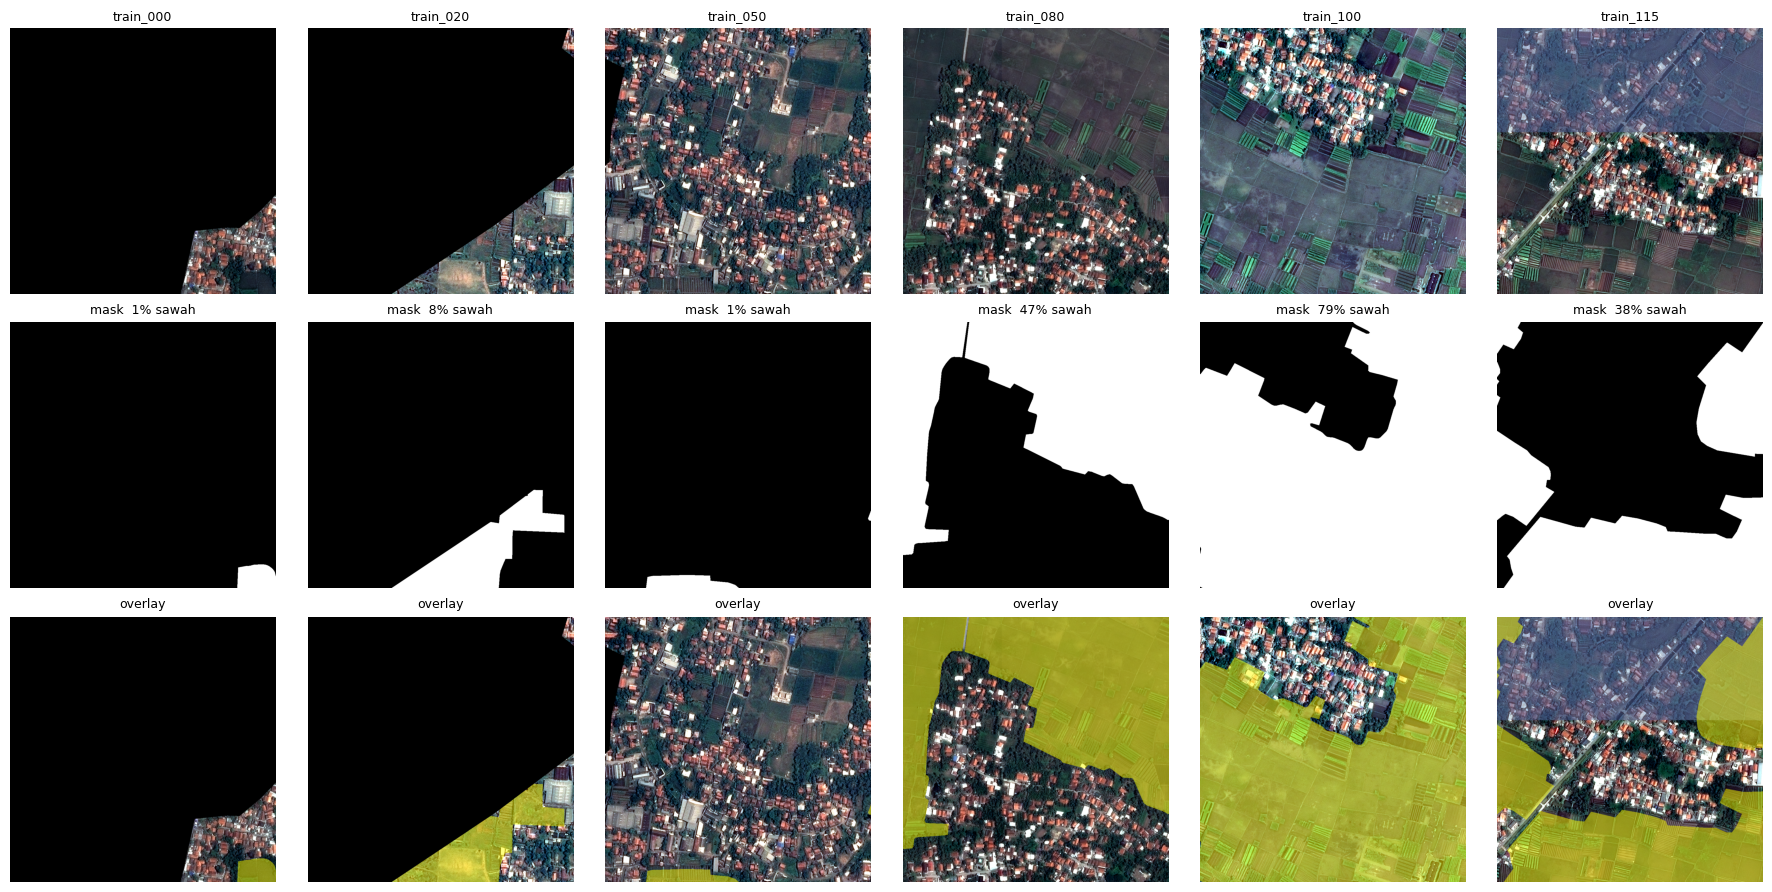

In [3]:
show = [train_ids[k] for k in (0, 20, 50, 80, 100, 115)]
fig, ax = plt.subplots(3, len(show), figsize=(3 * len(show), 9))
for c, i in enumerate(show):
    im, m = train_img(i), train_mask(i)
    over = im.copy(); over[m] = (0.5 * over[m] + 0.5 * np.array([255, 255, 0])).astype(np.uint8)
    for r, (pic, t) in enumerate(((im, i), (m, f"mask  {m.mean():.0%} sawah"), (over, "overlay"))):
        ax[r, c].imshow(pic, cmap="gray"); ax[r, c].set_title(t, fontsize=9); ax[r, c].axis("off")
plt.tight_layout(); plt.show()

### 1.3 Statistik per tile (resolusi seperempat sudah cukup untuk statistik)

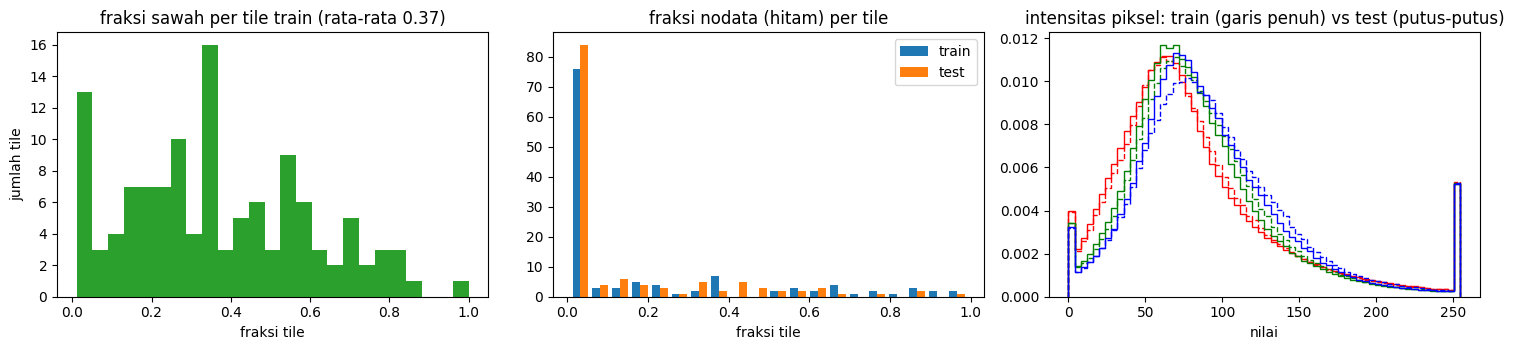

piksel sawah di train: 37.1%
piksel nodata: train 19.0%, test 14.1%
piksel nodata yang berlabel sawah di train: 0.83%
rata-rata RGB train [81.7 85.5 91.5] | test [82.8 88.3 94.7]


In [4]:
S = 4
tr = np.stack([train_img(i)[::S, ::S] for i in train_ids])
tm = np.stack([train_mask(i)[::S, ::S] for i in train_ids])
te = np.stack([test_img(i)[::S, ::S] for i in test_ids])
tr_black, te_black = (tr == 0).all(-1), (te == 0).all(-1)

paddy = tm.reshape(len(tm), -1).mean(1)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(paddy, bins=25, color="C2"); ax[0].set(title=f"fraksi sawah per tile train (rata-rata {paddy.mean():.2f})", xlabel="fraksi tile", ylabel="jumlah tile")
ax[1].hist([tr_black.reshape(len(tr), -1).mean(1), te_black.reshape(len(te), -1).mean(1)], bins=20, label=["train", "test"])
ax[1].set(title="fraksi nodata (hitam) per tile", xlabel="fraksi tile"); ax[1].legend()
valid_tr, valid_te = tr[~tr_black], te[~te_black]
for k, col in enumerate("rgb"):
    ax[2].hist(valid_tr[:, k], bins=64, range=(0, 255), histtype="step", color=col, density=True)
    ax[2].hist(valid_te[:, k], bins=64, range=(0, 255), histtype="step", color=col, density=True, linestyle="--")
ax[2].set(title="intensitas piksel: train (garis penuh) vs test (putus-putus)", xlabel="nilai")
plt.tight_layout(); plt.show()

print(f"piksel sawah di train: {tm.mean():.1%}")
print(f"piksel nodata: train {tr_black.mean():.1%}, test {te_black.mean():.1%}")
print(f"piksel nodata yang berlabel sawah di train: {(tm & tr_black).sum() / tr_black.sum():.2%}")
print("rata-rata RGB train", valid_tr.mean(0).round(1), "| test", valid_te.mean(0).round(1))

### 1.4 Tile saling tumpang-tindih

Tile dipotong dengan stride 512 piksel, sehingga tile bertetangga berbagi separuh luasnya. Kuadran 512×512 yang sama dapat ditemukan langsung dari piksel. Akibatnya, tile validasi yang diambil acak hampir selalu punya tetangga di sisi train, dan skor validasinya lebih tinggi daripada skor pada blok yang benar-benar terpisah — masalah ketergantungan spasial yang sudah dikenal di penginderaan jauh [2, 3].

123 tile train membentuk 74 grup overlap; grup terbesar 12 tile; 54 tile tidak overlap dengan tile lain


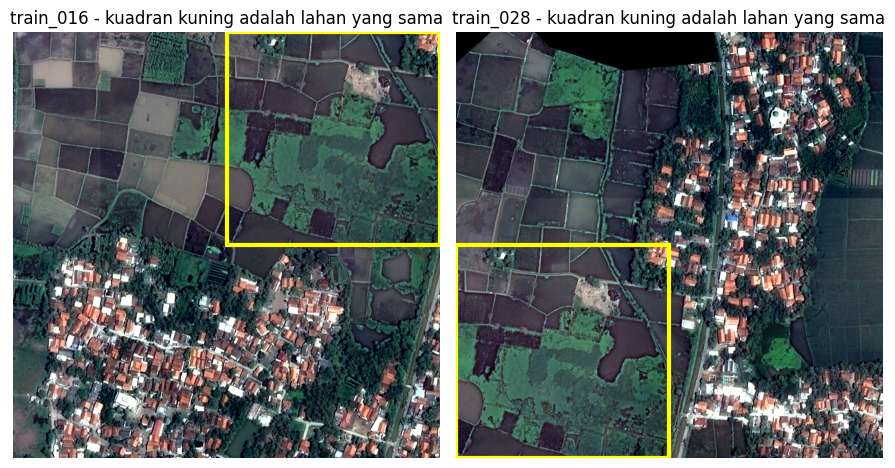

In [5]:
import paddy_repro as R

class Lazy:  # membaca tile satu per satu
    def __init__(self, ids, fn): self.ids, self.fn = ids, fn
    def __len__(self): return len(self.ids)
    def __iter__(self): return (self.fn(i) for i in self.ids)

grp = R.tile_groups(Lazy(train_ids, train_img))
sizes = pd.Series(grp).value_counts()
print(f"{len(train_ids)} tile train membentuk {len(sizes)} grup overlap; grup terbesar {sizes.iloc[0]} tile; {int((sizes == 1).sum())} tile tidak overlap dengan tile lain")

big = [i for i, g in enumerate(grp) if g == sizes.index[0]]
a = train_img(train_ids[big[0]])
quad = lambda im, r, c: cv2.resize(cv2.cvtColor(im[r*512:(r+1)*512, c*512:(c+1)*512], cv2.COLOR_RGB2GRAY), (24, 24), interpolation=cv2.INTER_AREA).astype(np.float32)
pair = None
for j in big[1:]:
    b = train_img(train_ids[j])
    for ra, ca, rb, cb in ((ra, ca, rb, cb) for ra in (0, 1) for ca in (0, 1) for rb in (0, 1) for cb in (0, 1)):
        if ((quad(a, ra, ca) - quad(b, rb, cb)) ** 2).mean() < 9:
            pair = (j, b, (ra, ca), (rb, cb)); break
    if pair: break
j, b, qa, qb = pair
fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))
for x, im, q, name in ((ax[0], a, qa, train_ids[big[0]]), (ax[1], b, qb, train_ids[j])):
    x.imshow(im); x.add_patch(plt.Rectangle((q[1] * 512, q[0] * 512), 512, 512, fill=False, edgecolor="yellow", linewidth=3))
    x.set_title(f"{name} - kuadran kuning adalah lahan yang sama"); x.axis("off")
plt.tight_layout(); plt.show()

### 1.5 Bentuk label

Mask train terdiri atas beberapa region besar dan padat per tile. Inilah dasar perapian mask di bagian 2.5.

In [6]:
def shape_stats(m):
    a = m.astype(np.uint8)
    n, _, st, _ = cv2.connectedComponentsWithStats(a, connectivity=4)
    nh, _, sh, _ = cv2.connectedComponentsWithStats(1 - a, connectivity=4)
    return n - 1, int((sh[1:, 4] < 2000).sum()), int((st[1:, 4] < 5000).sum())

st = pd.DataFrame([shape_stats(train_mask(i)) for i in train_ids], columns=["region sawah", "lubang < 2000 px", "region < 5000 px"])
st.describe().loc[["mean", "50%", "max"]].round(2)

,region sawah,lubang < 2000 px,region < 5000 px
mean,2.99,0.73,0.72
50%,3.00,0.00,0.00
max,10.00,6.00,5.00


## 2. Preprocessing

### 2.1 Split validasi

25 dari 123 tile train ditahan (satu dari lima lipatan permutasi acak yang tetap) dan 98 tile dipakai melatih. Karena tile saling overlap (1.4), sebagian besar tile validasi punya tetangga di sisi train. Skor validasi karena itu dibaca sebagai **cek kewajaran** (model belajar, tidak rusak), bukan perkiraan skor leaderboard, dan tidak dipakai untuk memilih bobot ensemble: keempat model diberi bobot sama.

In [7]:
val = R.holdout(len(train_ids))
trn = [i for i in range(len(train_ids)) if i not in set(val)]
trn_groups = {grp[i] for i in trn}
leak = sum(grp[i] in trn_groups for i in val)
print(f"train {len(trn)} tile, validasi {len(val)} tile")
print(f"{leak} dari {len(val)} tile validasi berbagi lahan dengan tile train -> skor validasi optimistis")
print("fraksi sawah validasi %.2f vs train %.2f" % (paddy[val].mean(), paddy[trn].mean()))

train 98 tile, validasi 25 tile
15 dari 25 tile validasi berbagi lahan dengan tile train -> skor validasi optimistis
fraksi sawah validasi 0.42 vs train 0.36


### 2.2 Augmentasi

Setiap sampel latih adalah crop acak yang mencakup 25–100 % luas tile, di-resize ke 768×768, dengan flip, rotasi 90° dan perubahan ringan brightness / contrast / hue. Empat crop per tile per epoch. Crop berskala acak membuat model melihat petak sawah pada berbagai ukuran; flip dan rotasi sah karena citra nadir tidak punya arah "atas".

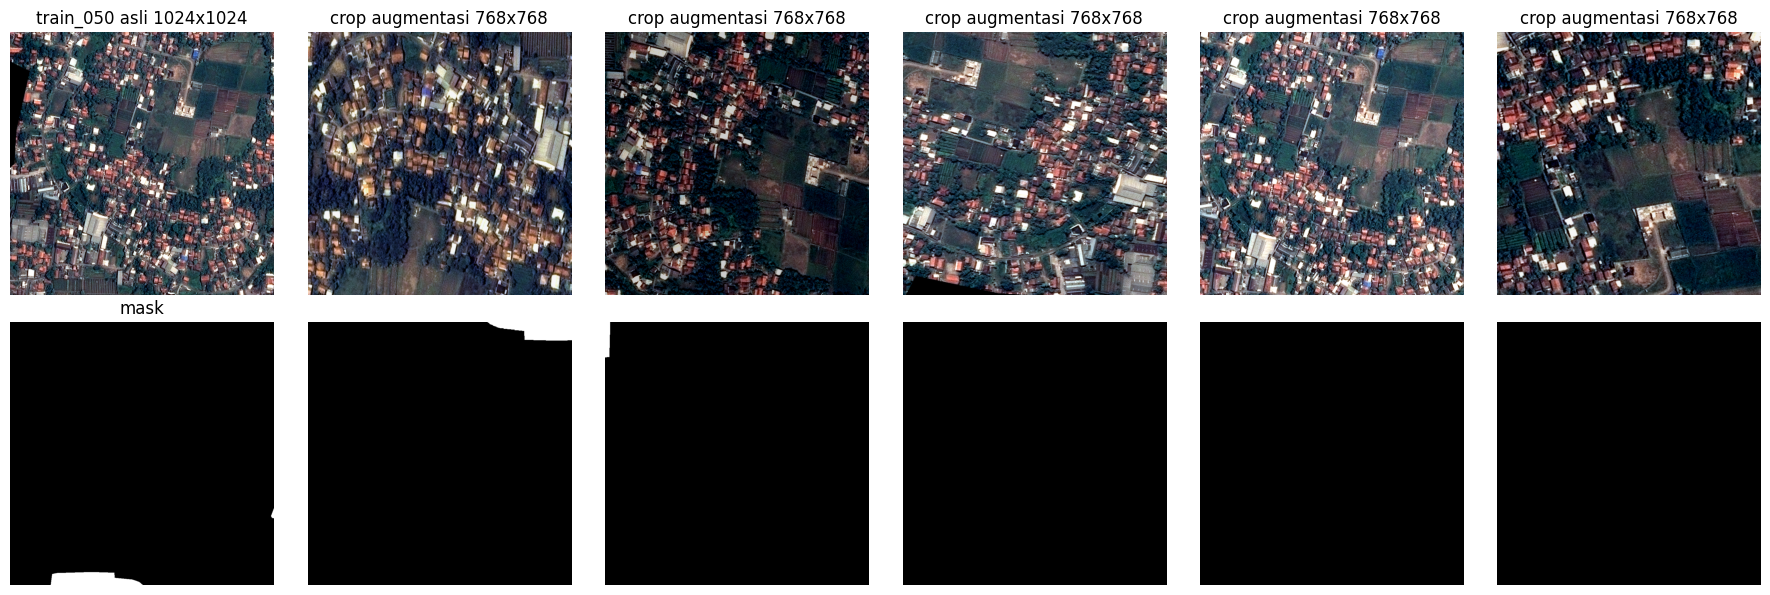

In [8]:
aug = R.make_aug()
i = train_ids[50]
im, m = train_img(i), train_mask(i).astype(np.float32)
fig, ax = plt.subplots(2, 6, figsize=(18, 6))
ax[0, 0].imshow(im); ax[0, 0].set_title(f"{i} asli 1024x1024"); ax[1, 0].imshow(m, cmap="gray"); ax[1, 0].set_title("mask")
for c in range(1, 6):
    o = aug(image=im, mask=m)
    ax[0, c].imshow(o["image"]); ax[0, c].set_title(f"crop augmentasi {o['image'].shape[0]}x{o['image'].shape[1]}"); ax[1, c].imshow(o["mask"], cmap="gray")
for x in ax.ravel(): x.axis("off")
plt.tight_layout(); plt.show()

### 2.3 Normalisasi per backbone

Piksel diskalakan dengan mean / simpangan baku yang dipakai saat backbone di-pretrain: statistik ImageNet untuk EfficientNetV2 dan Swin, statistik citra satelit untuk DINOv3-sat. Ukuran input 768 (latih) dan 1024 (inferensi) habis dibagi 32 dan 16, sesuai stride encoder dan ukuran patch ViT.

In [9]:
stats = {"ImageNet (EfficientNetV2-L, Swin-L)": ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
         "SAT-493M (DINOv3 ViT-L sat)": ((0.430, 0.411, 0.296), (0.213, 0.156, 0.143))}
x = train_img(train_ids[50]).astype(np.float32) / 255
rows = []
for name, (mean, std) in stats.items():
    z = (x - np.array(mean)) / np.array(std)
    rows.append({"statistik": name, "mean": mean, "std": std, "mean setelah normalisasi": z.mean((0, 1)).round(2), "std setelah normalisasi": z.std((0, 1)).round(2)})
pd.DataFrame(rows)

,statistik,mean,std,mean setelah normalisasi,std setelah normalisasi
0,"ImageNet (EfficientNetV2-L, Swin-L)","(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)","[-0.72, -0.59, -0.26]","[0.98, 0.89, 0.87]"
1,SAT-493M (DINOv3 ViT-L sat),"(0.43, 0.411, 0.296)","(0.213, 0.156, 0.143)","[-0.52, -0.56, 0.36]","[1.05, 1.27, 1.37]"


### 2.4 Nodata dan ketidakseimbangan kelas

- **Nodata.** Piksel hitam murni berada di luar jejak citra. Di data train hampir seluruhnya berlabel latar (lihat 1.3), jadi saat inferensi piksel hitam langsung ditetapkan sebagai latar.
- **Kelas.** Sawah mencakup sekitar 37 % piksel train, dengan sebaran per tile dari hampir 0 sampai 100 %. Loss yang dipakai adalah BCE + Dice [10]; Dice dihitung atas seluruh batch sehingga searah dengan metrik micro-IoU kompetisi (TP/FP/FN dijumlahkan lintas tile).

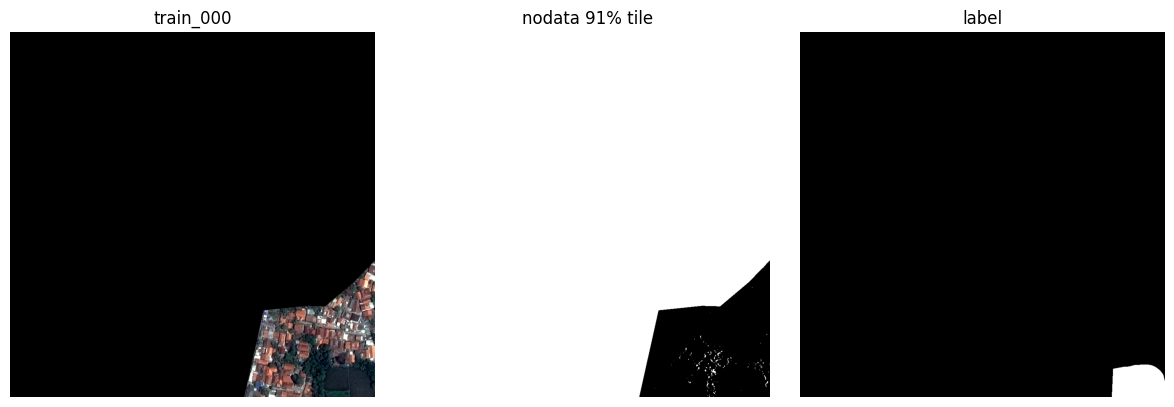

tile dengan fraksi sawah < 5%: 13, > 95%: 1, dari 123


In [10]:
i = train_ids[0]
im, m = train_img(i), train_mask(i)
black = (im == 0).all(2)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for x, pic, t in zip(ax, (im, black, m), (i, f"nodata {black.mean():.0%} tile", "label")):
    x.imshow(pic, cmap="gray"); x.set_title(t); x.axis("off")
plt.tight_layout(); plt.show()
print(f"tile dengan fraksi sawah < 5%: {(paddy < 0.05).sum()}, > 95%: {(paddy > 0.95).sum()}, dari {len(paddy)}")

### 2.5 Perapian mask (pasca-proses)

Diperagakan pada mask train yang diberi derau sintetis, jadi tidak perlu model: blur, threshold, closing, tutup lubang < 2000 px, buang region < 5000 px. Fungsi yang sama dipakai untuk submission. Dasarnya adalah bentuk label di 1.5: label hampir tidak punya lubang atau region sekecil itu.

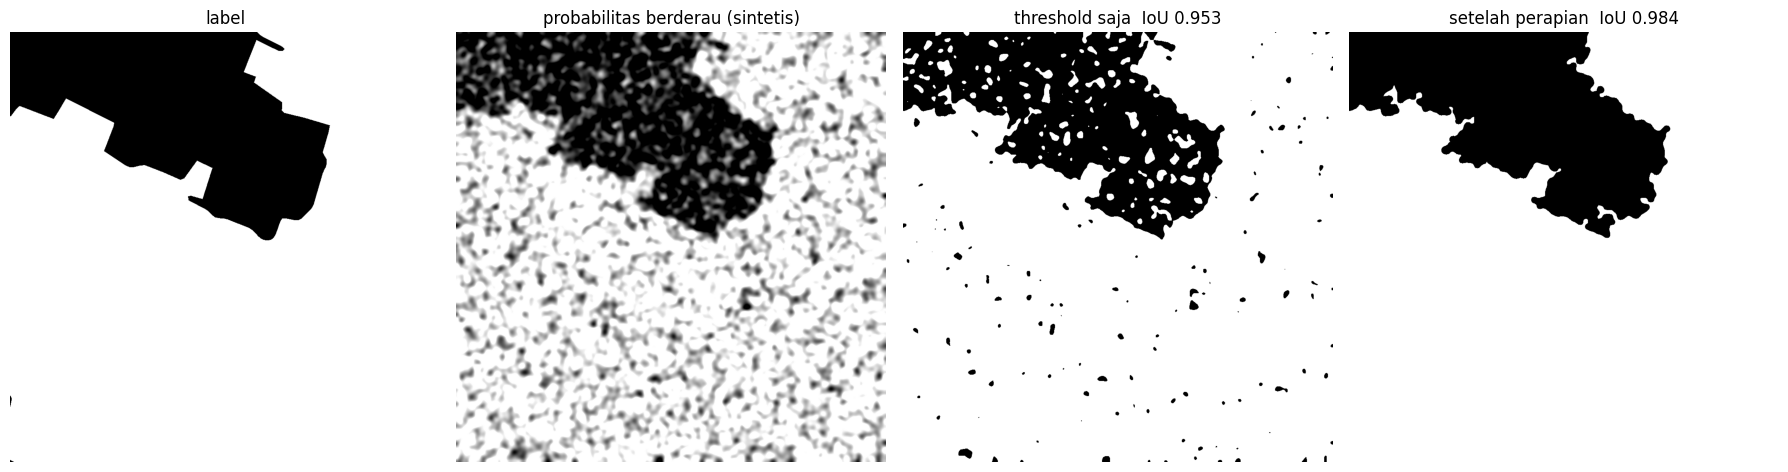

setelan akhir: {'thr': 0.35, 'sigma': 2, 'close': 15, 'hole': 2000, 'speck': 5000}


In [11]:
rng = np.random.RandomState(0)
m = train_mask(train_ids[100]).astype(np.float32)
noisy = np.clip(cv2.GaussianBlur(m, (0, 0), 6) + cv2.GaussianBlur(rng.randn(*m.shape).astype(np.float32), (0, 0), 6) * 6, 0, 1)
raw, clean = noisy > R.FINAL["thr"], R.postprocess(noisy, **R.FINAL)
iou = lambda p, g: (p & g).sum() / (p | g).sum()
fig, ax = plt.subplots(1, 4, figsize=(18, 4.6))
for x, pic, t in zip(ax, (m, noisy, raw, clean), ("label", "probabilitas berderau (sintetis)", f"threshold saja  IoU {iou(raw, m > 0):.3f}", f"setelah perapian  IoU {iou(clean, m > 0):.3f}")):
    x.imshow(pic, cmap="gray"); x.set_title(t); x.axis("off")
plt.tight_layout(); plt.show()
print("setelan akhir:", R.FINAL)

## 3. Training

Semua cell di bawah butuh GPU. `R._selfcheck()` memeriksa orientasi RLE (column-major, berbasis 1), fungsi perapian, dan determinisme split.

Resep yang sama untuk keempat model: crop 768, batch 4, AdamW (lr 1e-4 untuk head/decoder, 1e-5 untuk backbone pretrained DINOv3 dan Swin), one-cycle dengan warm-up 5 %, 60 epoch, mixed precision (Mask2Former fp32), loss BCE + Dice (Mask2Former memakai loss set-prediction bawaannya). Inferensi pada tile penuh 1024×1024 dengan TTA 4 flip.

In [ ]:
R._selfcheck()
print("model:", R.ENSEMBLE, "|", R.EPOCHS, "epoch")

### 3.1 DINOv3 ViT-L/16 (pretraining satelit) [4]

In [ ]:
R.train_predict("dinov3_sat", DATA, WORK)

### 3.2 UNet++ dengan encoder EfficientNetV2-L [5, 6]

In [ ]:
R.train_predict("unetpp_effv2l", DATA, WORK)

### 3.3 UPerNet dengan backbone Swin-L [7, 8]

In [ ]:
R.train_predict("upernet_swinl", DATA, WORK)

### 3.4 Mask2Former dengan backbone Swin-L [9]

In [ ]:
R.train_predict("mask2former_swinl", DATA, WORK)

## 4. Ensemble dan submission

Rata-rata probabilitas keempat model dengan bobot sama, lalu perapian bentuk.

In [ ]:
prob = R.blend(WORK)
ids = pd.read_csv(DATA + "/sample_submission.csv").ImageId.tolist()
fig, ax = plt.subplots(3, 4, figsize=(16, 12))
for c in range(4):
    ax[0, c].imshow(test_img(ids[c])); ax[0, c].set_title(ids[c])
    ax[1, c].imshow(prob[c], cmap="viridis", vmin=0, vmax=1); ax[1, c].set_title("probabilitas rata-rata")
    ax[2, c].imshow(R.postprocess(prob[c], **R.FINAL), cmap="gray"); ax[2, c].set_title("mask akhir")
for x in ax.ravel(): x.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
path = R.make_submission(DATA, WORK)
sub = pd.read_csv(path, keep_default_na=False)
assert list(sub.columns) == ["ImageId", "EncodedPixels"] and len(sub) == 129
print(path, "|", (sub.EncodedPixels == "").sum(), "mask kosong")
sub.head()

## 5. Referensi

1. H. Setiadi, Y. Arifin. *A Multi-Region Pléiades-Derived Dataset for Paddy Field Segmentation across Five Agro-Ecological Zones in Indonesia.* Mendeley Data, 2026. doi:10.17632/g7vkrjr8dn.2 — konteks sumber citra dan asal label (peta vektor Lahan Baku Sawah).
2. N. Karasiak, J.-F. Dejoux, C. Monteil, D. Sheeren. *Spatial dependence between training and test sets: another pitfall of classification accuracy assessment in remote sensing.* Machine Learning 111, 2715–2740, 2022.
3. D. R. Roberts dkk. *Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure.* Ecography 40, 913–929, 2017.
4. O. Siméoni dkk. *DINOv3.* arXiv:2508.10104, 2025.
5. Z. Zhou, M. M. R. Siddiquee, N. Tajbakhsh, J. Liang. *UNet++: A Nested U-Net Architecture for Medical Image Segmentation.* DLMIA 2018. arXiv:1807.10165.
6. M. Tan, Q. V. Le. *EfficientNetV2: Smaller Models and Faster Training.* ICML 2021. arXiv:2104.00298.
7. T. Xiao, Y. Liu, B. Zhou, Y. Jiang, J. Sun. *Unified Perceptual Parsing for Scene Understanding.* ECCV 2018. arXiv:1807.10221.
8. Z. Liu dkk. *Swin Transformer: Hierarchical Vision Transformer using Shifted Windows.* ICCV 2021. arXiv:2103.14030.
9. B. Cheng, I. Misra, A. G. Schwing, A. Kirillov, R. Girdhar. *Masked-attention Mask Transformer for Universal Image Segmentation.* CVPR 2022. arXiv:2112.01527.
10. F. Milletari, N. Navab, S.-A. Ahmadi. *V-Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation* (Dice loss). 3DV 2016. arXiv:1606.04797.